In [1]:
import matplotlib.pyplot as plt
from numpy import diag, exp, linspace, min, max, sqrt, meshgrid, reshape, abs, shape, mean, arange, zeros, polyfit, poly1d, trapz
import numpy as np
from scipy.interpolate import interp1d
from scipy import optimize
import cv2
from os import path, listdir
import xmltodict
import pandas as pd
from scipy.special import ndtr as norm_cdf

In [2]:
def ncdf(x, c, w):
    z = (x - c) / w
    return norm_cdf(z)

def gaussian(x, c, w):
    z = (x - c) / w
    return exp(-0.5 * z**2)

def hsv_cal_1d(z, shape):
    g = gaussian(z, 0.0, 1000.)
    f = ncdf(z, 1, shape)
    return g * (1 - f)

def hsv_cal_2d_fit(xy, x0, y0, wx, wy, shape, amp, offset):
    x, y = xy
    z = sqrt(((x - x0) / wx) ** 2 + ((y - y0) / wy) ** 2)
    
    output = amp * hsv_cal_1d(z, shape) + offset
    
    return output.ravel()

def fit_image(img):
    
    '''
    
    '''
    # img_filename = 'N:/CCFE/MAST-U/Operations/Diagnostics/Planning/09-10 Visible Cameras/2024-03 Calibration/SAX2 B_C001H001S0002/SAX2 B_C001H001S0002000001.bmp'
    #
    
    #fit_data = img[500,:]
    
    img_shape = shape(img)
    
    x = linspace(0, img_shape[0]-1, img_shape[0])
    y = linspace(0, img_shape[1]-1, img_shape[1])
    
    xgrid, ygrid = meshgrid(x, y)
    
#     p0 = [0.5*img_shape[0], 0.5*img_shape[1], 150, 150, 0.2, max(img), min(img)]
    p0 = [0.5*img_shape[0], 0.5*img_shape[1], 150, 150, 0.2, 
          img[img_shape[0]//2,img_shape[1]//2], min(img)]
    #    (x0, y0, wx, wy, shape, amp, offset)
    boo0 = ~np.isclose(img, 4095) | np.isclose(img, 0)
#     opt, cov = optimize.curve_fit(hsv_cal_2d_fit, (xgrid, ygrid), img.ravel(), p0)
    opt, cov = optimize.curve_fit(hsv_cal_2d_fit, (xgrid[boo0], ygrid[boo0]), img[boo0].ravel(), p0)
    cov = sqrt(diag(cov))
    
    imgfit = reshape(hsv_cal_2d_fit((xgrid, ygrid), *opt), shape(img))
    
    ### this is where the maximum is (those lines)
    ### and where the background is - offset+1 is the cutoff
    boo = np.isclose(img, img.max()) | (imgfit < (opt[-1]+1.)) | np.isclose(img, 0.)
    
    ### simple absolute difference
    residual = mean(abs(imgfit[~boo] - img[~boo]))
    ### RMS
    residual2 = np.sqrt(mean((imgfit[~boo] - img[~boo])**2))
    percentages = (imgfit[~boo] - img[~boo]) / img[~boo] # not *100.
    res_perc = mean(abs(percentages))
    res2_perc = np.sqrt(mean(abs(percentages)**2))
    
    return (opt, residual, imgfit, cov, residual2, mean(abs(img[~boo])), res_perc, res2_perc)
    
    
    
    # Generate a flat-field correction to the data, which should just be the reciprocal
    # of the fitted image
    
def generate_flat_field(opt, img_size, thresh = 5.0):
    
    '''
    Generates a flat-field correction matrix based on a 2D fit performed of an image
    of a uniform illumination light source, such as an integrating sphere.  The
    size of the flat-fied correction matrix is taken from the dimensions of
    the input image, img.  In cases where there is severe vignetting, flat-field
    scale factors greater than thresh are set to zero, to mask off the part of
    the image where the flat-field correction is very high, due to low signal
    in the calibration image
    
    Inputs:
        - opt: flat-field calibration values
        - img_size: a 2 element touple containing the dimensions of the flat-field image
        
    Outputs:
        - An image of size (img_size) that can be multipled to a camera image
          to perform flat-field correction
    '''
    
    x = linspace(0, img_size[0]-1, img_size[0])
    y = linspace(0, img_size[1]-1, img_size[1])
    
    xgrid, ygrid = meshgrid(x, y)
    
    flat_field = reshape(1.0 / hsv_cal_2d_fit((xgrid, ygrid), opt[0],opt[1],opt[2],opt[3],opt[4],opt[5],1.0,0.0), shape(img_size))
    flat_field[flat_field > thresh] = 0
    
    return flat_field

def get_cih(filename):
    name, ext = path.splitext(filename)
    if ext == '.cih':
        cih = dict()
        # read the cif header
        with open(filename, 'r') as f:
            for line in f:
                if line == '\n': #end of cif header
                    break
                line_sp = line.replace('\n', '').split(' : ')
                if len(line_sp) == 2:
                    key, value = line_sp
                    try:
                        if '.' in value:
                            value = float(value)
                        else:
                            value = int(value)
                        cih[key] = value
                    except:
                        cih[key] = value

    elif ext == '.cihx':
        with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
            first_last_line = [ i for i in range(len(lines)) if '<cih>' in lines[i] or '</cih>' in lines[i] ]
            xml = ''.join(lines[first_last_line[0]:first_last_line[-1]+1])

        raw_cih_dict = xmltodict.parse(xml)
        cih = {
            'Date': raw_cih_dict['cih']['fileInfo']['date'], 
            'Camera Type': raw_cih_dict['cih']['deviceInfo']['deviceName'],
            'Record Rate(fps)': float(raw_cih_dict['cih']['recordInfo']['recordRate']),
            'Shutter Speed(s)': float(raw_cih_dict['cih']['recordInfo']['shutterSpeed']),
            'Total Frame': int(raw_cih_dict['cih']['frameInfo']['totalFrame']),
            'Original Total Frame': int(raw_cih_dict['cih']['frameInfo']['recordedFrame']),
            'Image Width': int(raw_cih_dict['cih']['imageDataInfo']['resolution']['width']),
            'Image Height': int(raw_cih_dict['cih']['imageDataInfo']['resolution']['height']),
            'File Format': raw_cih_dict['cih']['imageFileInfo']['fileFormat'],
            'EffectiveBit Depth': int(raw_cih_dict['cih']['imageDataInfo']['effectiveBit']['depth']),
            'EffectiveBit Side': raw_cih_dict['cih']['imageDataInfo']['effectiveBit']['side'],
            'Color Bit': int(raw_cih_dict['cih']['imageDataInfo']['colorInfo']['bit']),
            'Comment Text': raw_cih_dict['cih']['basicInfo'].get('comment', ''),
        }
        
    return cih

def integrating_sphere_radiance(luminance, min_wl, max_wl):
    
    full_dat = pd.read_excel('integrating_sphere_data.xlsx','100% 50mm port',header=None)
    full_luminance = 14.15
    
    twenty_dat = pd.read_excel('integrating_sphere_data.xlsx','20% 50mm port',header=None)
    twenty_luminance = 2.868
    
    scaled_dat = full_dat.copy()
    scaled_dat[1] = scaled_dat[1] * luminance / full_luminance
    
    calib_interp = interp1d(scaled_dat[0], scaled_dat[1])
    
    filter_wl = linspace(min_wl - 1, max_wl + 1, max_wl - min_wl + 3)
    filter_transmission = filter_wl.copy() * 0.0
    filter_transmission[1:-1] = 1
    
    calib_radiance = calib_interp(filter_wl)
    
    return trapz(calib_radiance * filter_transmission, filter_wl)

In [3]:
# Read the calibration image
img_dir = './images/'

# img_files = ['SAX2 B_C001H001S0019000001.png',
#              'SAX2 B_C001H001S0020000001.png',
#              'SAX2 B_C001H001S0021000001.png',
#              'SAX2 B_C001H001S0022000001.png',
#              'SAX2 B_C001H001S0023000001.png',
#              'SAX2 B_C001H001S0024000001.png']

# header_files = ['SAX2 B_C001H001S0019.cihx',
#                 'SAX2 B_C001H001S0020.cihx',
#                 'SAX2 B_C001H001S0021.cihx',
#                 'SAX2 B_C001H001S0022.cihx',
#                 'SAX2 B_C001H001S0023.cihx',
#                 'SAX2 B_C001H001S0024.cihx']

### remove first file
img_files = ['SAX2 B_C001H001S0020000001.png',
             'SAX2 B_C001H001S0021000001.png',
             'SAX2 B_C001H001S0022000001.png',
             'SAX2 B_C001H001S0023000001.png',
             'SAX2 B_C001H001S0024000001.png']

header_files = ['SAX2 B_C001H001S0020.cihx',
                'SAX2 B_C001H001S0021.cihx',
                'SAX2 B_C001H001S0022.cihx',
                'SAX2 B_C001H001S0023.cihx',
                'SAX2 B_C001H001S0024.cihx']

# Integrating sphere brightness, in kcd/m
sphere_brightness = [6.445]*len(img_files)

phot_flux = zeros(len(img_files))

fit_results = zeros((len(img_files),7))
residuals = zeros(len(img_files))
fit_frames = zeros(((len(img_files),1024,1024)))
fit_pcov = zeros((len(img_files),7))
residuals2 = zeros(len(img_files))
means = zeros(len(img_files))
res_percs = zeros(len(img_files))
res2_percs = zeros(len(img_files))

shutter_speeds = zeros(len(img_files))
exposure_times = zeros(len(img_files))
record_rates = zeros(len(img_files))


peak_signal = []
background = []

In [4]:
%matplotlib widget

/tmp/ipykernel_19258/3524437089.py:68: RuntimeWarning: divide by zero encountered in divide
  diff = (img - fit_result[2]) / img * 100.
/tmp/ipykernel_19258/3524437089.py:68: RuntimeWarning: divide by zero encountered in divide
  diff = (img - fit_result[2]) / img * 100.
/tmp/ipykernel_19258/3524437089.py:68: RuntimeWarning: divide by zero encountered in divide
  diff = (img - fit_result[2]) / img * 100.
/tmp/ipykernel_19258/3524437089.py:68: RuntimeWarning: divide by zero encountered in divide
  diff = (img - fit_result[2]) / img * 100.
/tmp/ipykernel_19258/3524437089.py:68: RuntimeWarning: divide by zero encountered in divide
  diff = (img - fit_result[2]) / img * 100.


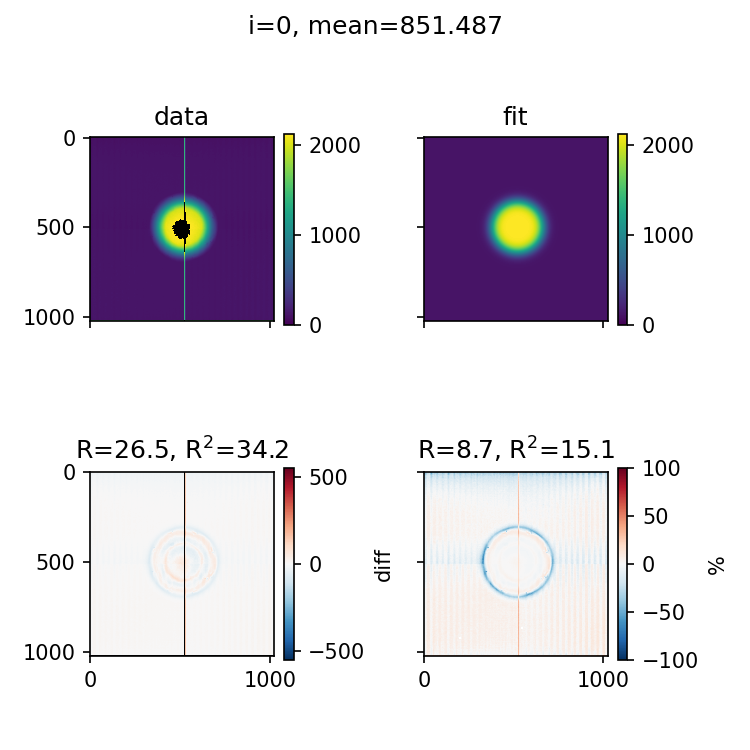

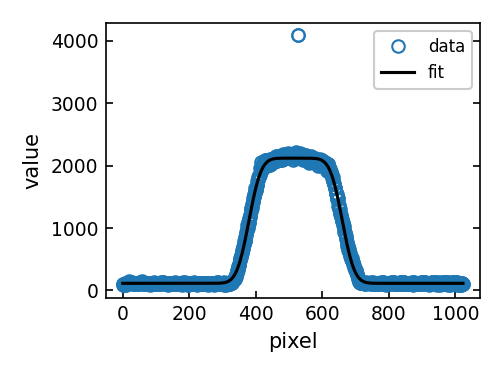

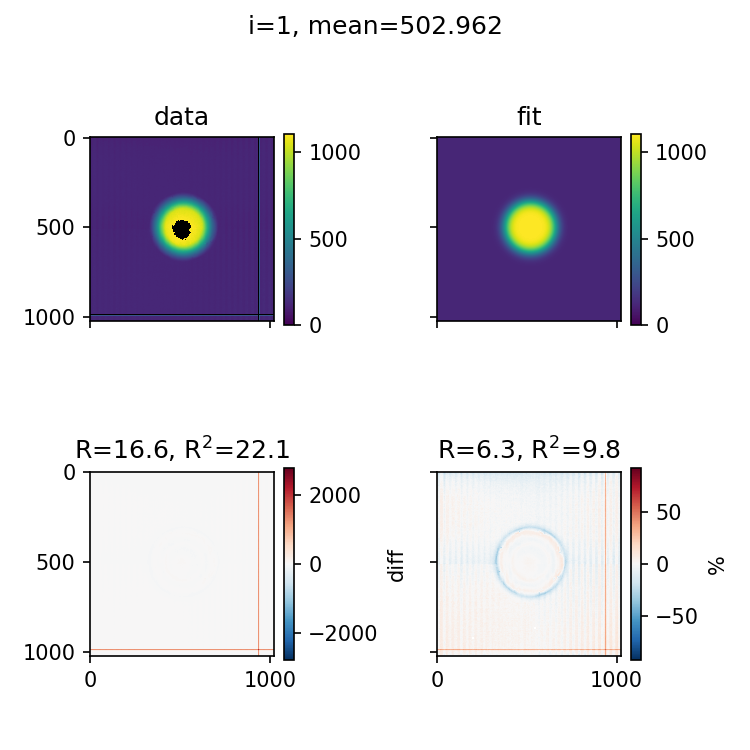

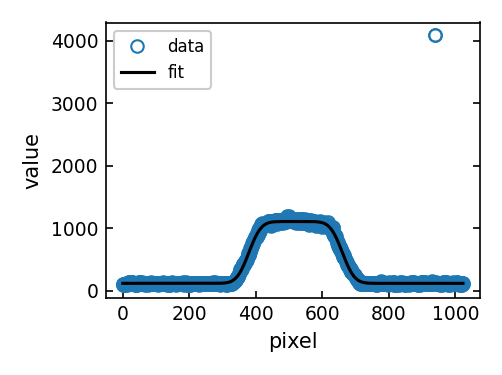

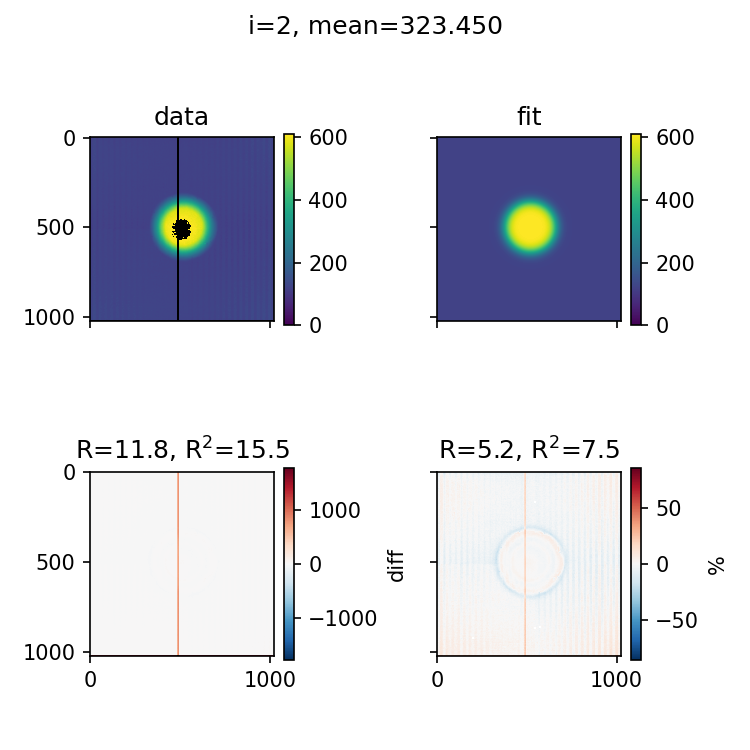

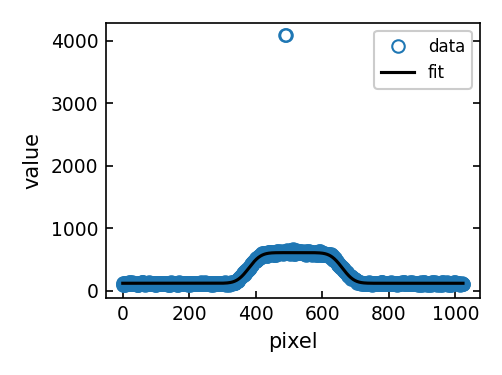

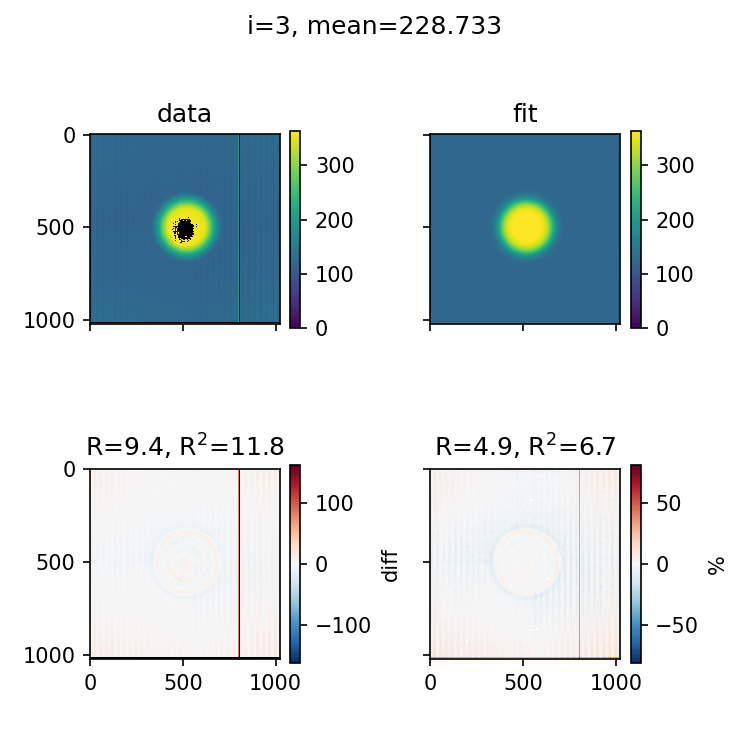

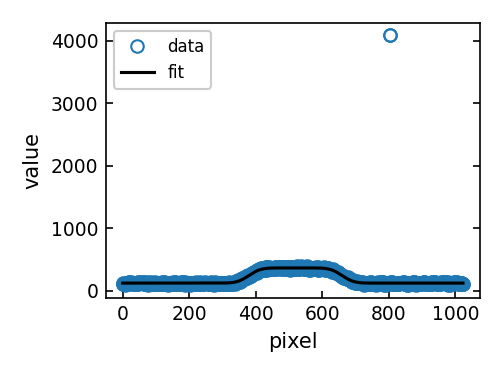

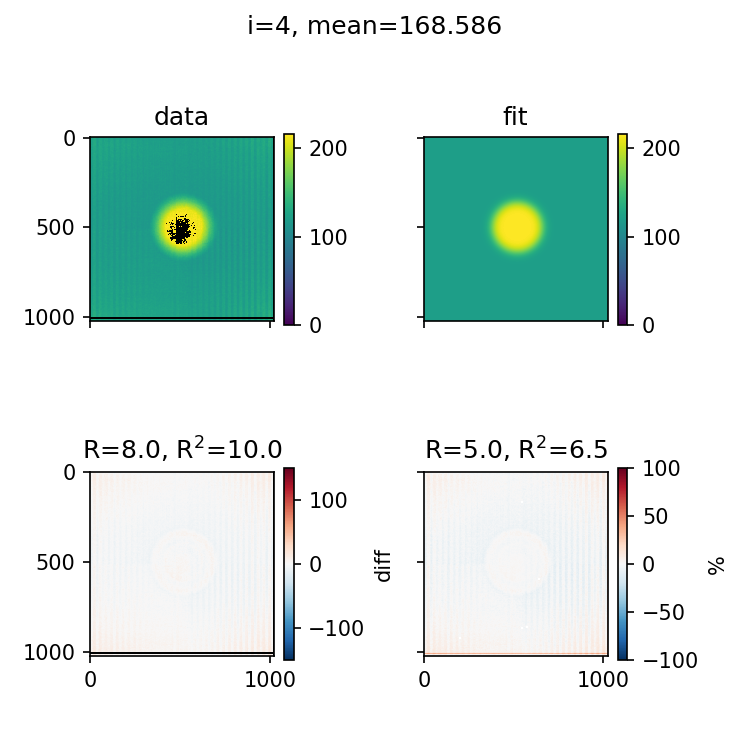

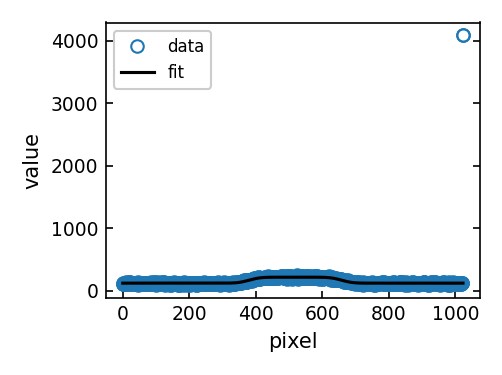

In [5]:
for i in arange(len(img_files)):
# for i in [3]:

    img = cv2.imread(img_dir + img_files[i],cv2.IMREAD_UNCHANGED)

    # Read the header file
    header = get_cih(img_dir + header_files[i])

    exposure_time = 1.0 / header['Shutter Speed(s)']
    shutter_speeds[i] = header['Shutter Speed(s)']
    exposure_times[i] = exposure_time
    record_rates[i] = header['Record Rate(fps)']

    fit_result = fit_image(img) # fits a 2D gaussian basically

    fit_results[i,:] = fit_result[0]
    residuals[i] = fit_result[1]
    fit_frames[i,:,:] = fit_result[2]
    fit_pcov[i,:] = fit_result[3]
    residuals2[i] = fit_result[4]
    means[i] = fit_result[5]
    res_percs[i] = fit_result[6]
    res2_percs[i] = fit_result[7]

    # calculate the photon energy
    wl = 656.0E-9
    phot_e = (6.6E-34) * (3E8) / wl

    # Calculate the radiance from the integrating sphere, in
    # units of W / m^-2 / sr
    srad = integrating_sphere_radiance(sphere_brightness[i], 656 - 5, 656 + 5) * 1.0E-3

    # Convert to units of photons / s / m^-2 / sr
    srad_phot = srad / phot_e

    # Store the photon flux to the sensor for each image
    phot_flux[i] = srad_phot * exposure_time
    
    
    fig, ax = plt.subplots(2, 2, figsize=(5,5), dpi=150, sharex=True, sharey=True)
    mx = fit_result[0][-2] + fit_result[0][-1]
    cmap = plt.cm.get_cmap('viridis')
    cmap.set_over(color='black')
    
    im1=ax[0,0].imshow(img, vmin=0, vmax=mx, cmap=cmap)
    fig.colorbar(im1, ax=ax[0,0], fraction=0.047)
    ax[0,0].title.set_text('data')
    ax[0,0].set_aspect('equal')
    
    im2=ax[0,1].imshow(fit_result[2], vmin=0, vmax=mx, cmap=cmap)
    fig.colorbar(im2, ax=ax[0,1], fraction=0.047)
    ax[0,1].title.set_text('fit')
    ax[0,1].set_aspect('equal')
    
    
    boo = np.isclose(img, img.max()) | (fit_result[2] < (fit_result[0][-1]+1.0)) | np.isclose(img, 0.)
    
    diff = (img - fit_result[2])
    lev = abs(diff[~boo]).max()
    cmap = plt.cm.RdBu_r
    cmap.set_over(color='black')
    cmap.set_under(color='black')
    im4=ax[1,0].imshow(diff, vmin=-lev, vmax=lev, cmap=plt.cm.RdBu_r)
    fig.colorbar(im4, ax=ax[1,0], fraction=0.047, label='diff')
    ax[1,0].title.set_text(f'R={residuals[i]:.1f}, R$^2$={residuals2[i]:.1f}')
    ax[1,0].set_aspect('equal')
    
    diff = (img - fit_result[2]) / img * 100.
    lev = abs(diff[~boo]).max()
    if lev > 100.:
        lev = 100.
    cmap = plt.cm.RdBu_r
    cmap.set_over(color='black')
    cmap.set_under(color='black')
    im4=ax[1,1].imshow(diff, vmin=-lev, vmax=lev, cmap=plt.cm.RdBu_r)
    fig.colorbar(im4, ax=ax[1,1], fraction=0.047, label='%')
    ax[1,1].title.set_text(f'R={100.*res_percs[i]:.1f}, R$^2$={100.*res2_percs[i]:.1f}')
    ax[1,1].set_aspect('equal')
    
    fig.suptitle(f'i={i}, mean={means[i]:.3f}')
    plt.tight_layout()
    
    fig, ax = plt.subplots(1, 1, figsize=(3.35,2.5), dpi=150)
    ax.plot(img[512], 'o', c='C0', mec='C0', mfc='None', label='data')
    ax.plot(fit_result[2][512], '-k', label='fit')
    ax.legend(fancybox=1, framealpha=1, fontsize=8)
    ax.set_xlabel('pixel')
    ax.set_ylabel('value')
    ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
    plt.tight_layout()

In [6]:
def linfunc(x, m, c):
    return m * x + c

def linerr(x, m, c):
    return np.sqrt((x * m)**2 + c**2)

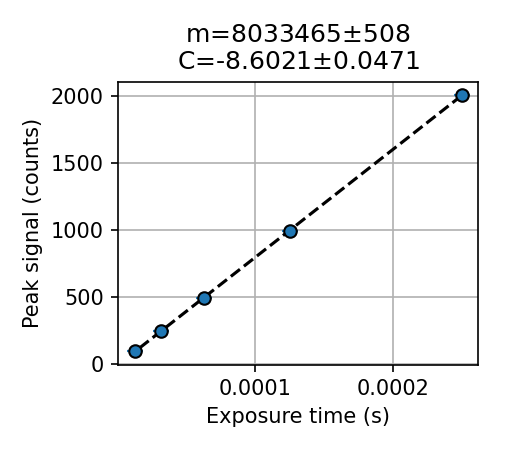

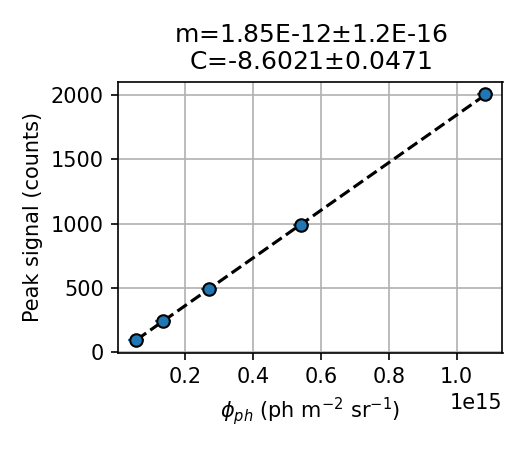

In [7]:
plt.figure(figsize=(3.5,3), dpi=150)

# Plot the peak signal recorded by the camera as a function of exposure
# time.  To do this, take the peak signal values from the fit results and
# subtract the background signal
peak_signals = fit_results[:,-2]

plt.errorbar(exposure_times, peak_signals, fmt='o', mec='k', yerr=fit_pcov[:,-2], capsize=4)
plt.xlabel('Exposure time (s)')
plt.ylabel('Peak signal (counts)')
plt.grid()

# Plot a linear fit through the data
# calib_fit, calib_fit_err = polyfit(exposure_times, peak_signals, 1, cov=True)
calib_fit, calib_fit_err = optimize.curve_fit(linfunc, exposure_times, peak_signals, 
                                             sigma=fit_pcov[:,-2], absolute_sigma=True)
calib_fit_err = sqrt(diag(calib_fit_err))

tmp = poly1d(calib_fit)
plt.plot(exposure_times, tmp(exposure_times), '--k')

plt.title(f'm={calib_fit[0]:.0f}$\\pm${calib_fit_err[0]:.0f}\nC={calib_fit[1]:.4f}$\\pm${calib_fit_err[1]:.4f}')
plt.tight_layout()

# Plot the calibration data in terms of photon flux
plt.figure(figsize=(3.5,3), dpi=150)
plt.errorbar(phot_flux, peak_signals, fmt='o', mec='k', yerr=fit_pcov[:,-2], capsize=4)
plt.xlabel(r'$\phi_{ph}$ (ph m$^{-2}$ sr$^{-1}$)')
plt.ylabel('Peak signal (counts)')
plt.grid()

# calib_fit_phot, calib_fit_phot_err = polyfit(phot_flux, peak_signals, 1, cov=True)
calib_fit_phot, calib_fit_phot_err = optimize.curve_fit(linfunc, phot_flux, peak_signals, 
                                                        sigma=fit_pcov[:,-2], absolute_sigma=True)
calib_fit_phot_err = sqrt(diag(calib_fit_phot_err))

tmp_phot = poly1d(calib_fit_phot)
plt.plot(phot_flux, tmp_phot(phot_flux), '--k')

calib_factor_phot = 1.0 / calib_fit_phot[0]

plt.title(f'm={calib_fit_phot[0]:.2E}$\\pm${calib_fit_phot_err[0]:.1E}\nC={calib_fit_phot[1]:.4f}$\\pm${calib_fit_phot_err[1]:.4f}')
plt.tight_layout()

In [8]:
p0 = [512, 512, 150, 150,   0.2, img[512,512], 0]
p0strings = ('x0', 'y0', 'wx', 'wy', 'shape', 'amp', 'offset')

In [9]:
# xwant = 20e-6 * 1e3
# sf = 2
# myys = np.zeros(len(p0))
# myyerrs = np.zeros(len(p0))

# for I in range(0, len(p0)):
#     fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
#     ax.errorbar(exposure_times*1e3, fit_results[:,I], yerr=fit_pcov[:,I], fmt='o', c='C0', mec='k', capsize=4, label='fits')
#     ax.set_xlabel('exposure times (ms)', fontsize=9)
#     ax.set_ylabel(p0strings[I], fontsize=9)
#     ax.title.set_text(p0strings[I])
#     ax.set_xlim([0.,0.0003*1e3])
#     popt, pcov = optimize.curve_fit(linfunc, exposure_times*1e3, fit_results[:,I], 
#                                     sigma=fit_pcov[:,I], absolute_sigma=True)
#     pcov = np.sqrt(np.diag(pcov))
#     myfit = linfunc(exposure_times*1e3, *popt)
#     myy = linfunc(xwant, *popt)
#     myyerr = linerr(xwant, *pcov)
#     myys[I] = myy
#     myyerrs[I] = myyerr
#     dp = sf - int(np.floor(np.log10(myyerr))) - 1

#     ax.plot(exposure_times*1e3, myfit, '--', c='k', lw=0.8)
#     ax.plot(xwant, myy, 'x', c='C3', label=f'{p0strings[I]}={myy:.6f}\n$\\pm${myyerr:.6f}')
#     ax.legend(fancybox=1, framealpha=1, fontsize=8)

#     ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
#               left=True, bottom=True, right=True, top=False)
#     plt.tight_layout()

In [10]:
xwant = 20e-6 * 1e3
sf = 2
myys = np.zeros(len(p0))
myyerrs = np.zeros(len(p0))

In [11]:
def fitfunc(x, A, x0, C):
    return A / (x - x0) + C

def errfunc(x, A, x0, Aerr, x0err, Cerr):
    term1 = Aerr / (x - x0)
    term2 = (A * x0err) / (x - x0)**2
    term3 = Cerr
    return np.sqrt(term1**2 + term2**2 + term3**2)

xplot = np.linspace(exposure_times.min()*1e3, 0.3, 100)

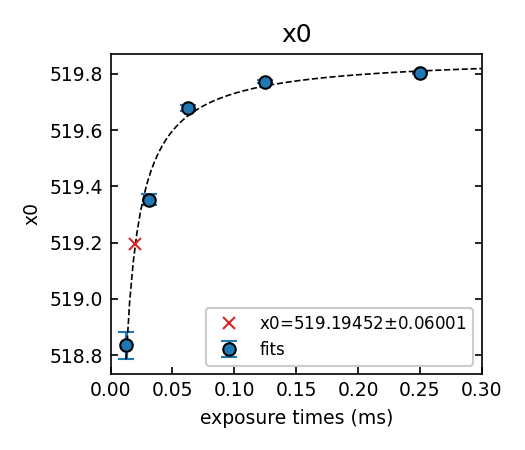

In [12]:
I = 0
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times*1e3, fit_results[:,I], yerr=fit_pcov[:,I], fmt='o', c='C0', mec='k', capsize=4, label='fits')
ax.set_xlabel('exposure times (ms)', fontsize=9)
ax.set_ylabel(p0strings[I], fontsize=9)
ax.title.set_text(p0strings[I])
ax.set_xlim([0.,0.0003*1e3])
popt, pcov = optimize.curve_fit(fitfunc, exposure_times*1e3, fit_results[:,I], 
                                sigma=fit_pcov[:,I], absolute_sigma=True, p0=(-0.01, 0., 519.5))
pcov = np.sqrt(np.diag(pcov))
myfit = fitfunc(xplot, *popt)
myy = fitfunc(xwant, *popt)
myyerr = errfunc(xwant, popt[0], popt[1], pcov[0], pcov[1], pcov[2])
myys[I] = myy
myyerrs[I] = myyerr
dp = sf - int(np.floor(np.log10(myyerr))) - 1

ax.plot(xplot, myfit, '--', c='k', lw=0.8)
ax.plot(xwant, myy, 'x', c='C3', label=f'{p0strings[I]}={myy:.5f}$\\pm${myyerr:.5f}')

# ax.plot(exposure_times*1e3, fitfunc(exposure_times*1e3, -0.01, 0., 519.5))
ax.legend(fancybox=1, framealpha=1, fontsize=8)

ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

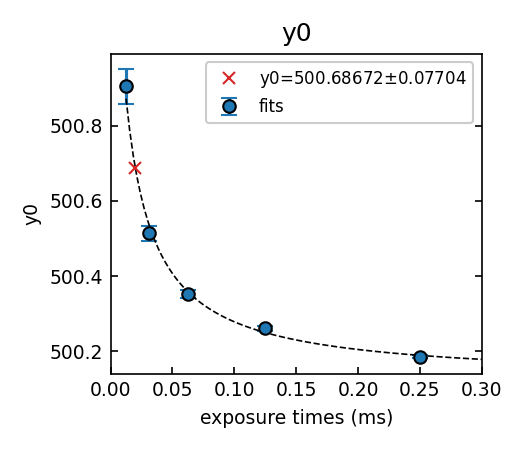

In [13]:
I = 1
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times*1e3, fit_results[:,I], yerr=fit_pcov[:,I], fmt='o', c='C0', mec='k', capsize=4, label='fits')
ax.set_xlabel('exposure times (ms)', fontsize=9)
ax.set_ylabel(p0strings[I], fontsize=9)
ax.title.set_text(p0strings[I])
ax.set_xlim([0.,0.0003*1e3])
popt, pcov = optimize.curve_fit(fitfunc, exposure_times*1e3, fit_results[:,I], 
                                sigma=fit_pcov[:,I], absolute_sigma=True, p0=(0.01, 0., 519.5))
pcov = np.sqrt(np.diag(pcov))
myfit = fitfunc(xplot, *popt)
myy = fitfunc(xwant, *popt)
myyerr = errfunc(xwant, popt[0], popt[1], pcov[0], pcov[1], pcov[2])
myys[I] = myy
myyerrs[I] = myyerr
dp = sf - int(np.floor(np.log10(myyerr))) - 1

ax.plot(xplot, myfit, '--', c='k', lw=0.8)
ax.plot(xwant, myy, 'x', c='C3', label=f'{p0strings[I]}={myy:.5f}$\\pm${myyerr:.5f}')

# ax.plot(exposure_times*1e3, fitfunc(exposure_times*1e3, -0.01, 0., 519.5))
ax.legend(fancybox=1, framealpha=1, fontsize=8)

ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

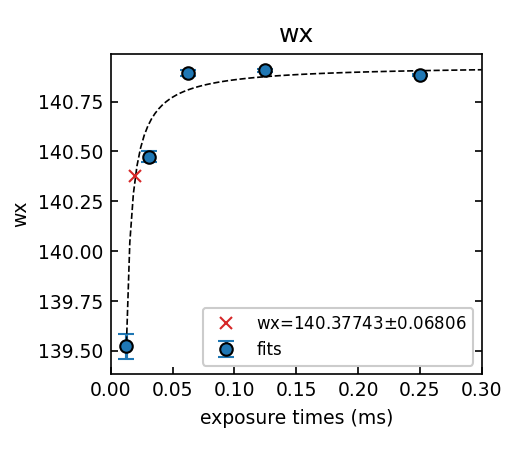

In [14]:
I = 2
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times*1e3, fit_results[:,I], yerr=fit_pcov[:,I], fmt='o', c='C0', mec='k', capsize=4, label='fits')
ax.set_xlabel('exposure times (ms)', fontsize=9)
ax.set_ylabel(p0strings[I], fontsize=9)
ax.title.set_text(p0strings[I])
ax.set_xlim([0.,0.0003*1e3])
popt, pcov = optimize.curve_fit(fitfunc, exposure_times*1e3, fit_results[:,I], 
                                sigma=fit_pcov[:,I], absolute_sigma=True, p0=(-0.01, 0., 141.))
pcov = np.sqrt(np.diag(pcov))
myfit = fitfunc(xplot, *popt)
myy = fitfunc(xwant, *popt)
myyerr = errfunc(xwant, popt[0], popt[1], pcov[0], pcov[1], pcov[2])
myys[I] = myy
myyerrs[I] = myyerr
dp = sf - int(np.floor(np.log10(myyerr))) - 1

ax.plot(xplot, myfit, '--', c='k', lw=0.8)
ax.plot(xwant, myy, 'x', c='C3', label=f'{p0strings[I]}={myy:.5f}$\\pm${myyerr:.5f}')

# ax.plot(exposure_times*1e3, fitfunc(exposure_times*1e3, -0.01, 0., 519.5))
ax.legend(fancybox=1, framealpha=1, fontsize=8)

ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

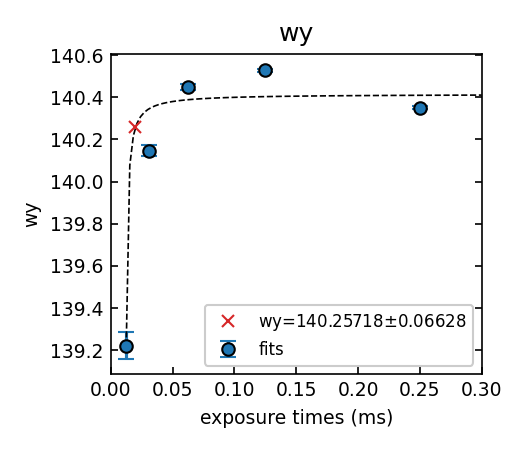

In [15]:
I = 3
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times*1e3, fit_results[:,I], yerr=fit_pcov[:,I], fmt='o', c='C0', mec='k', capsize=4, label='fits')
ax.set_xlabel('exposure times (ms)', fontsize=9)
ax.set_ylabel(p0strings[I], fontsize=9)
ax.title.set_text(p0strings[I])
ax.set_xlim([0.,0.0003*1e3])
popt, pcov = optimize.curve_fit(fitfunc, exposure_times*1e3, fit_results[:,I], 
                                sigma=fit_pcov[:,I], absolute_sigma=True, p0=(-0.01, 0., 141.))
pcov = np.sqrt(np.diag(pcov))
myfit = fitfunc(xplot, *popt)
myy = fitfunc(xwant, *popt)
myyerr = errfunc(xwant, popt[0], popt[1], pcov[0], pcov[1], pcov[2])
myys[I] = myy
myyerrs[I] = myyerr
dp = sf - int(np.floor(np.log10(myyerr))) - 1

ax.plot(xplot, myfit, '--', c='k', lw=0.8)
ax.plot(xwant, myy, 'x', c='C3', label=f'{p0strings[I]}={myy:.5f}$\\pm${myyerr:.5f}')

# ax.plot(exposure_times*1e3, fitfunc(exposure_times*1e3, -0.01, 0., 519.5))
ax.legend(fancybox=1, framealpha=1, fontsize=8)

ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

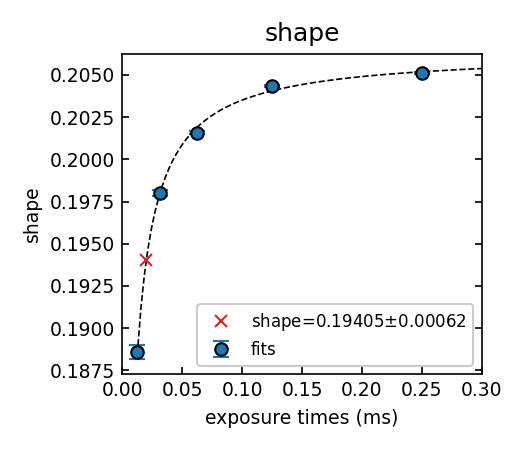

In [16]:
I = 4
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times*1e3, fit_results[:,I], yerr=fit_pcov[:,I], fmt='o', c='C0', mec='k', capsize=4, label='fits')
ax.set_xlabel('exposure times (ms)', fontsize=9)
ax.set_ylabel(p0strings[I], fontsize=9)
ax.title.set_text(p0strings[I])
ax.set_xlim([0.,0.0003*1e3])
popt, pcov = optimize.curve_fit(fitfunc, exposure_times*1e3, fit_results[:,I], 
                                sigma=fit_pcov[:,I], absolute_sigma=True, p0=(-0.01, 0., 141.))
pcov = np.sqrt(np.diag(pcov))
myfit = fitfunc(xplot, *popt)
myy = fitfunc(xwant, *popt)
myyerr = errfunc(xwant, popt[0], popt[1], pcov[0], pcov[1], pcov[2])
myys[I] = myy
myyerrs[I] = myyerr
dp = sf - int(np.floor(np.log10(myyerr))) - 1

ax.plot(xplot, myfit, '--', c='k', lw=0.8)
ax.plot(xwant, myy, 'x', c='C3', label=f'{p0strings[I]}={myy:.5f}$\\pm${myyerr:.5f}')

# ax.plot(exposure_times*1e3, fitfunc(exposure_times*1e3, -0.01, 0., 519.5))
ax.legend(fancybox=1, framealpha=1, fontsize=8)

ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

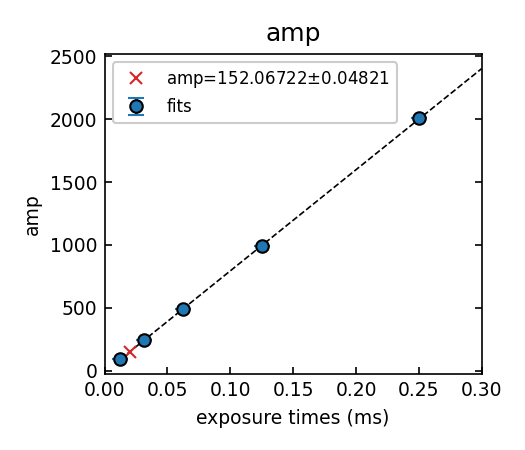

In [17]:
I = 5
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times*1e3, fit_results[:,I], yerr=fit_pcov[:,I], fmt='o', c='C0', mec='k', capsize=4, label='fits')
ax.set_xlabel('exposure times (ms)', fontsize=9)
ax.set_ylabel(p0strings[I], fontsize=9)
ax.title.set_text(p0strings[I])
ax.set_xlim([0.,0.0003*1e3])
popt, pcov = optimize.curve_fit(linfunc, exposure_times*1e3, fit_results[:,I], 
                                sigma=fit_pcov[:,I], absolute_sigma=True)
pcov = np.sqrt(np.diag(pcov))
myfit = linfunc(xplot, *popt)
myy = linfunc(xwant, *popt)
myyerr = linerr(xwant, *pcov)
myys[I] = myy
myyerrs[I] = myyerr
dp = sf - int(np.floor(np.log10(myyerr))) - 1

ax.plot(xplot, myfit, '--', c='k', lw=0.8)
ax.plot(xwant, myy, 'x', c='C3', label=f'{p0strings[I]}={myy:.5f}$\\pm${myyerr:.5f}')

# ax.plot(exposure_times*1e3, fitfunc(exposure_times*1e3, -0.01, 0., 519.5))
ax.legend(fancybox=1, framealpha=1, fontsize=8)

ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

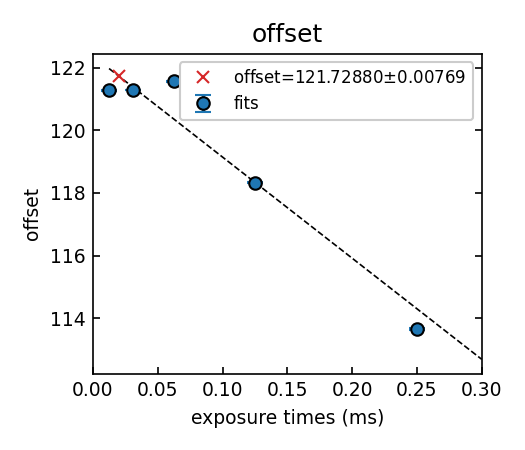

In [18]:
I = 6
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times*1e3, fit_results[:,I], yerr=fit_pcov[:,I], fmt='o', c='C0', mec='k', capsize=4, label='fits')
ax.set_xlabel('exposure times (ms)', fontsize=9)
ax.set_ylabel(p0strings[I], fontsize=9)
ax.title.set_text(p0strings[I])
ax.set_xlim([0.,0.0003*1e3])
popt, pcov = optimize.curve_fit(linfunc, exposure_times*1e3, fit_results[:,I], 
                                sigma=fit_pcov[:,I], absolute_sigma=True)
pcov = np.sqrt(np.diag(pcov))
myfit = linfunc(xplot, *popt)
myy = linfunc(xwant, *popt)
myyerr = linerr(xwant, *pcov)
myys[I] = myy
myyerrs[I] = myyerr
dp = sf - int(np.floor(np.log10(myyerr))) - 1

ax.plot(xplot, myfit, '--', c='k', lw=0.8)
ax.plot(xwant, myy, 'x', c='C3', label=f'{p0strings[I]}={myy:.5f}$\\pm${myyerr:.5f}')

# ax.plot(exposure_times*1e3, fitfunc(exposure_times*1e3, -0.01, 0., 519.5))
ax.legend(fancybox=1, framealpha=1, fontsize=8)

ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

/tmp/ipykernel_19258/1715884398.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)


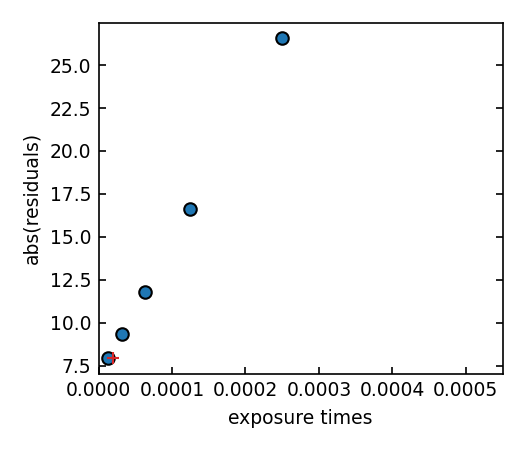

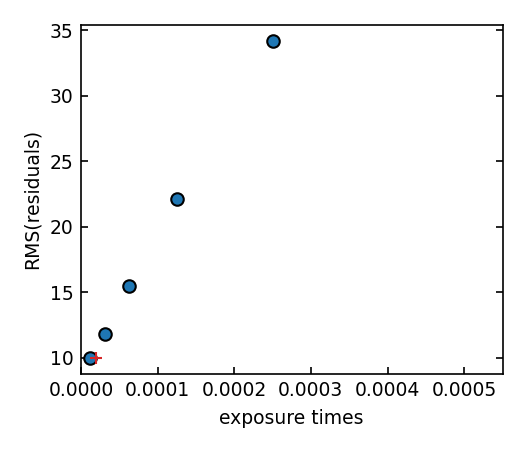

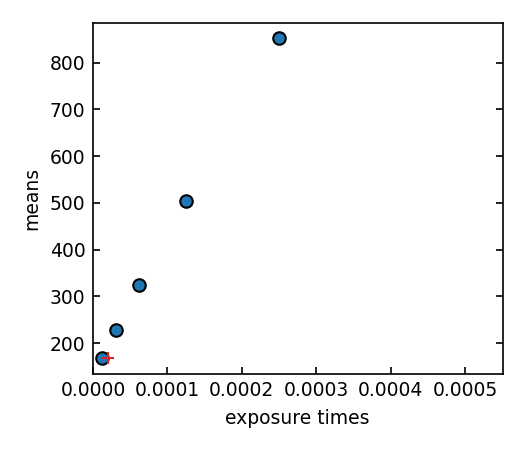

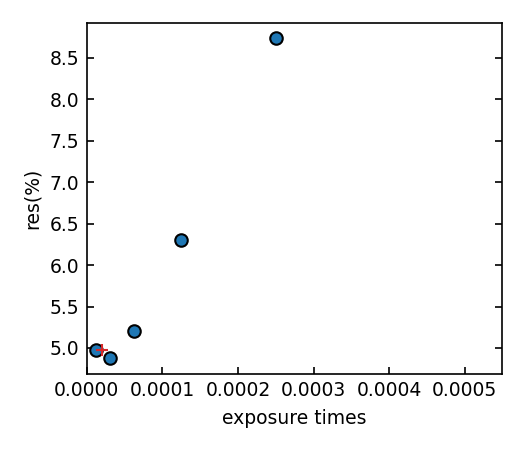

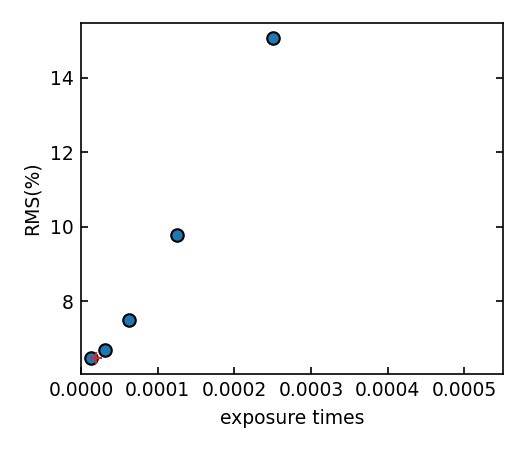

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times, residuals, fmt='o', c='C0', mec='k', capsize=4, label='residuals')
ax.plot(20e-6, np.interp(20e-6, exposure_times, residuals), '+', c='C3', zorder=4)
ax.set_xlabel('exposure times', fontsize=9)
ax.set_ylabel('abs(residuals)', fontsize=9)
ax.set_xlim([0.,0.00055])
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times, residuals2, fmt='o', c='C0', mec='k', capsize=4, label='residuals')
ax.plot(20e-6, np.interp(20e-6, exposure_times, residuals2), '+', c='C3', zorder=4)
ax.set_xlabel('exposure times', fontsize=9)
ax.set_ylabel('RMS(residuals)', fontsize=9)
ax.set_xlim([0.,0.00055])
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times, means, fmt='o', c='C0', mec='k', capsize=4, label='residuals')
ax.plot(20e-6, np.interp(20e-6, exposure_times, means), '+', c='C3', zorder=4)
ax.set_xlabel('exposure times', fontsize=9)
ax.set_ylabel('means', fontsize=9)
ax.set_xlim([0.,0.00055])
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times, res_percs*100., fmt='o', c='C0', mec='k', capsize=4, label='residuals')
ax.plot(20e-6, np.interp(20e-6, exposure_times, res_percs*100.), '+', c='C3', zorder=4)
ax.set_xlabel('exposure times', fontsize=9)
ax.set_ylabel('res(%)', fontsize=9)
ax.set_xlim([0.,0.00055])
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(exposure_times, res2_percs*100., fmt='o', c='C0', mec='k', capsize=4, label='residuals')
ax.plot(20e-6, np.interp(20e-6, exposure_times, res2_percs*100.), '+', c='C3', zorder=4)
ax.set_xlabel('exposure times', fontsize=9)
ax.set_ylabel('RMS(%)', fontsize=9)
ax.set_xlim([0.,0.00055])
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
plt.tight_layout()

In [20]:
x = np.linspace(0, 1023, 1024)
y = np.linspace(0, 1023, 1024)
xgrid, ygrid = np.meshgrid(x, y)

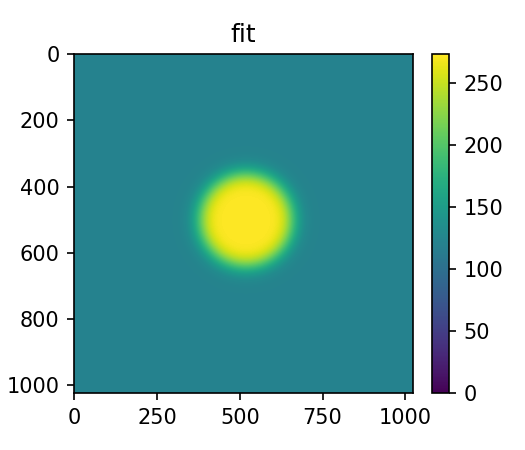

In [21]:
myguess = hsv_cal_2d_fit((xgrid,ygrid), *myys).reshape(xgrid.shape)
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
im=ax.imshow(myguess, vmin=0, vmax=myys[-2]+myys[-1], cmap=plt.cm.viridis)
fig.colorbar(im, ax=ax, fraction=0.047)
ax.title.set_text('fit')
ax.set_aspect('equal')
plt.tight_layout()

In [22]:
def linfunc0(x, m):
    return m * x

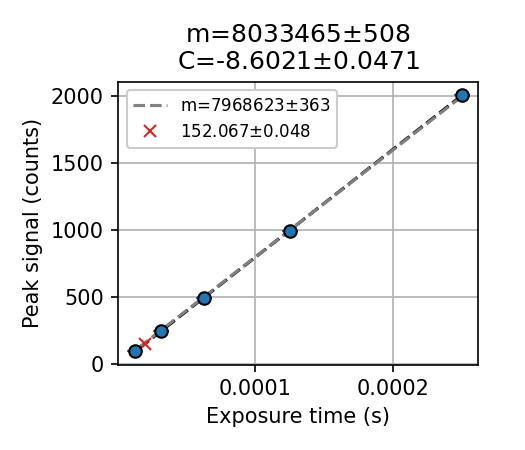

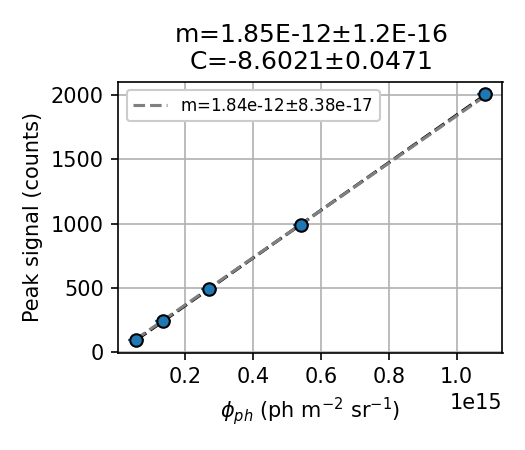

In [23]:
plt.figure(figsize=(3.5,3), dpi=150)

# Plot the peak signal recorded by the camera as a function of exposure
# time.  To do this, take the peak signal values from the fit results and
# subtract the background signal
peak_signals = fit_results[:,-2]

plt.errorbar(exposure_times, peak_signals, fmt='o', mec='k', yerr=fit_pcov[:,-2], capsize=4)
plt.xlabel('Exposure time (s)')
plt.ylabel('Peak signal (counts)')
plt.grid()

# Plot a linear fit through the data
# calib_fit, calib_fit_err = polyfit(exposure_times, peak_signals, 1, cov=True)
calib_fit, calib_fit_err = optimize.curve_fit(linfunc, exposure_times, peak_signals, 
                                             sigma=fit_pcov[:,-2], absolute_sigma=True)
calib_fit_err = sqrt(diag(calib_fit_err))
calib_fit0, calib_fit_err0 = optimize.curve_fit(linfunc0, exposure_times, peak_signals, 
                                                sigma=fit_pcov[:,-2], absolute_sigma=True)
calib_fit_err0 = sqrt(diag(calib_fit_err0))

tmp = poly1d(calib_fit)
plt.plot(exposure_times, tmp(exposure_times), '--k')
plt.plot(exposure_times, exposure_times * calib_fit0, '--', c='gray', 
         label=f'm={calib_fit0[0]:.0f}$\\pm${calib_fit_err0[0]:.0f}')

plt.title(f'm={calib_fit[0]:.0f}$\\pm${calib_fit_err[0]:.0f}\nC={calib_fit[1]:.4f}$\\pm${calib_fit_err[1]:.4f}')

ywant = linfunc(xwant/1e3, *calib_fit)
ywanterr = linerr(xwant/1e3, *calib_fit_err)

plt.plot(xwant/1e3, ywant, 'x', c='C3', label=f'{ywant:.3f}$\\pm${ywanterr:.3f}')
plt.legend(fancybox=1, framealpha=1, fontsize=8)
plt.tight_layout()



# Plot the calibration data in terms of photon flux
plt.figure(figsize=(3.5,3), dpi=150)
plt.errorbar(phot_flux, peak_signals, fmt='o', mec='k', yerr=fit_pcov[:,-2], capsize=4)
plt.xlabel(r'$\phi_{ph}$ (ph m$^{-2}$ sr$^{-1}$)')
plt.ylabel('Peak signal (counts)')
plt.grid()

# calib_fit_phot, calib_fit_phot_err = polyfit(phot_flux, peak_signals, 1, cov=True)
calib_fit_phot, calib_fit_phot_err = optimize.curve_fit(linfunc, phot_flux, peak_signals, 
                                                        sigma=fit_pcov[:,-2], absolute_sigma=True)
calib_fit_phot_err = sqrt(diag(calib_fit_phot_err))
calib_fit_phot0, calib_fit_phot_err0 = optimize.curve_fit(linfunc0, phot_flux, peak_signals, 
                                                        sigma=fit_pcov[:,-2], absolute_sigma=True)
calib_fit_phot_err0 = sqrt(diag(calib_fit_phot_err0))

tmp_phot = poly1d(calib_fit_phot)
plt.plot(phot_flux, tmp_phot(phot_flux), '--k')

calib_factor_phot = 1.0 / calib_fit_phot[0]
plt.plot(phot_flux, phot_flux * calib_fit_phot0, '--', c='gray', 
         label=f'm={calib_fit_phot0[0]:.3g}$\\pm${calib_fit_phot_err0[0]:.3g}')
plt.legend(fancybox=1, framealpha=1, fontsize=8)
plt.title(f'm={calib_fit_phot[0]:.2E}$\\pm${calib_fit_phot_err[0]:.1E}\nC={calib_fit_phot[1]:.4f}$\\pm${calib_fit_phot_err[1]:.4f}')

plt.tight_layout()

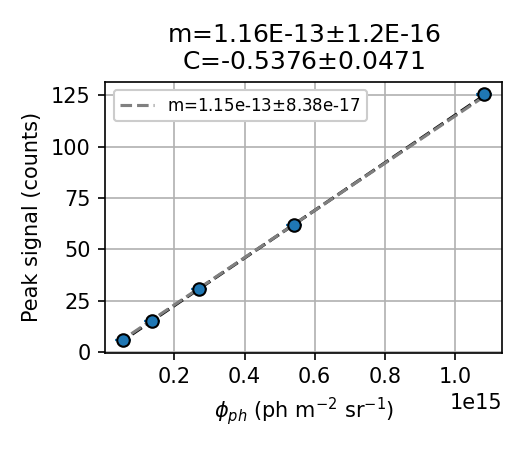

In [24]:
# Plot the calibration data in terms of photon flux
plt.figure(figsize=(3.5,3), dpi=150)
plt.errorbar(phot_flux, peak_signals / 16., fmt='o', mec='k', yerr=fit_pcov[:,-2], capsize=4)
plt.xlabel(r'$\phi_{ph}$ (ph m$^{-2}$ sr$^{-1}$)')
plt.ylabel('Peak signal (counts)')
plt.grid()

# calib_fit_phot, calib_fit_phot_err = polyfit(phot_flux, peak_signals, 1, cov=True)
calib_fit_phot, calib_fit_phot_err = optimize.curve_fit(linfunc, phot_flux, peak_signals / 16., 
                                                        sigma=fit_pcov[:,-2], absolute_sigma=True)
calib_fit_phot_err = sqrt(diag(calib_fit_phot_err))
calib_fit_phot0, calib_fit_phot_err0 = optimize.curve_fit(linfunc0, phot_flux, peak_signals / 16., 
                                                        sigma=fit_pcov[:,-2], absolute_sigma=True)
calib_fit_phot_err0 = sqrt(diag(calib_fit_phot_err0))

tmp_phot = poly1d(calib_fit_phot)
plt.plot(phot_flux, tmp_phot(phot_flux), '--k')

calib_factor_phot = 1.0 / calib_fit_phot0[0]
plt.plot(phot_flux, phot_flux * calib_fit_phot0, '--', c='gray', 
         label=f'm={calib_fit_phot0[0]:.3g}$\\pm${calib_fit_phot_err0[0]:.3g}')
plt.legend(fancybox=1, framealpha=1, fontsize=8)
plt.title(f'm={calib_fit_phot[0]:.2E}$\\pm${calib_fit_phot_err[0]:.1E}\nC={calib_fit_phot[1]:.4f}$\\pm${calib_fit_phot_err[1]:.4f}')

plt.tight_layout()

In [25]:
print('the calibration factor')
print(f'{calib_factor_phot:.6g}')

the calibration factor
8.70507e+12


In [26]:
print('calib err')
print(f'{calib_fit_phot_err0[0] / calib_fit_phot0[0]**2:.6g}')

calib err
6.3514e+09


In [27]:
1.16e-13 * 16.

1.856e-12

In [28]:
for i, I in enumerate(myys):
    print(p0strings[i], I, myyerrs[i])

x0 519.1945179431439 0.06000735459583017
y0 500.6867238544257 0.07704491125209063
wx 140.37743050654805 0.06806061339592126
wy 140.25717883104522 0.06627576825839374
shape 0.19404575950736763 0.0006188904617354492
amp 152.0672166427076 0.04821127024448594
offset 121.72880323526434 0.0076873684179332765


In [29]:
print(calib_fit_phot0[0], calib_fit_phot_err0[0])

1.1487555671871474e-13 8.381552545085605e-17


In [30]:
from mastu import HSV

In [31]:
test = HSV.vignette()

In [32]:
test.shape

(1024, 1024)

In [33]:
np.isclose(test, myguess).all(), np.isclose(myguess, test).all()

(False, False)

In [34]:
diff = myguess - test
mx = np.abs(diff).max()
perc = (myguess - test) / myguess * 100.
mxx = np.abs(perc).max()

In [35]:
diff.max(), diff.min()

(0.0025304151560021637, -0.0010481214299886688)

In [36]:
perc.min(), perc.max()

(-0.0007031844578088427, 0.0011583510539600358)

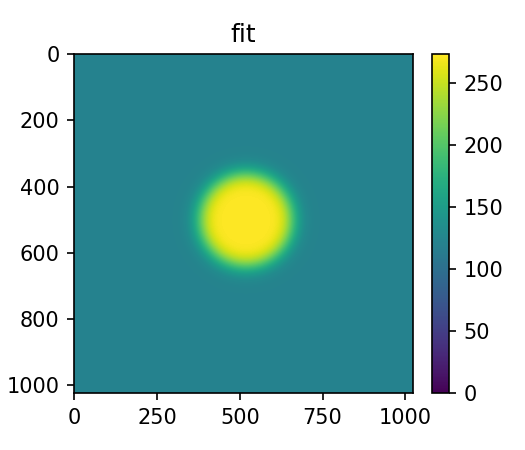

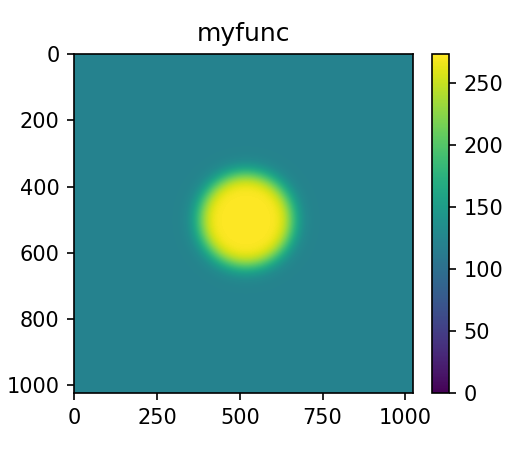

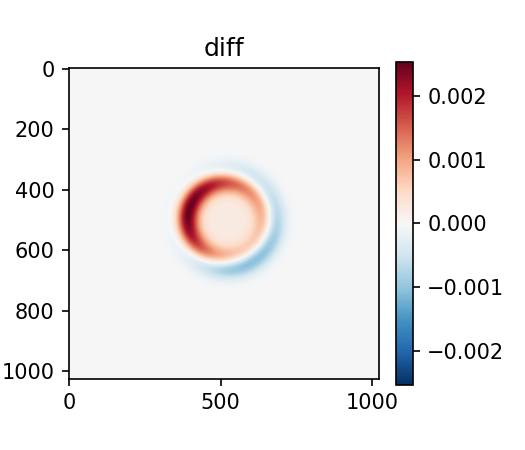

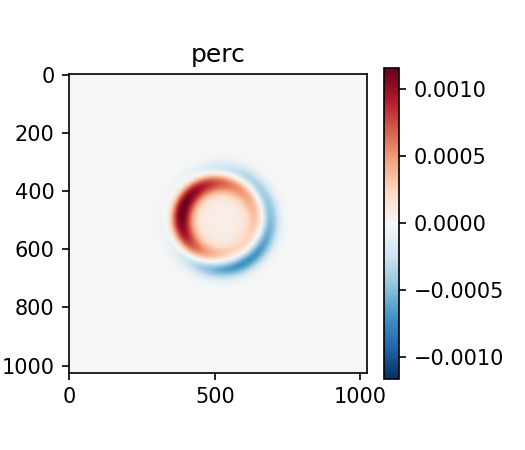

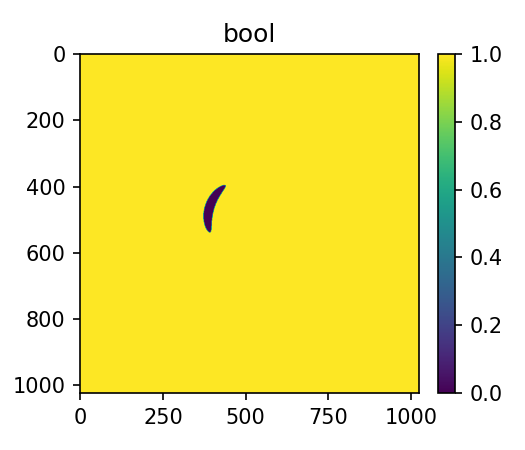

In [37]:
myguess = hsv_cal_2d_fit((xgrid,ygrid), *myys).reshape(xgrid.shape)
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
im=ax.imshow(myguess, vmin=0, vmax=myys[-2]+myys[-1], cmap=plt.cm.viridis)
fig.colorbar(im, ax=ax, fraction=0.047)
ax.title.set_text('fit')
ax.set_aspect('equal')
plt.tight_layout()
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
im=ax.imshow(test, vmin=0, vmax=myys[-2]+myys[-1], cmap=plt.cm.viridis)
fig.colorbar(im, ax=ax, fraction=0.047)
ax.title.set_text('myfunc')
ax.set_aspect('equal')
plt.tight_layout()
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
im=ax.imshow(diff, vmin=-mx, vmax=mx, cmap=plt.cm.RdBu_r)
fig.colorbar(im, ax=ax, fraction=0.047)
ax.title.set_text('diff')
ax.set_aspect('equal')
plt.tight_layout()
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
im=ax.imshow(perc, vmin=-mxx, vmax=mxx, cmap=plt.cm.RdBu_r)
fig.colorbar(im, ax=ax, fraction=0.047)
ax.title.set_text('perc')
ax.set_aspect('equal')
plt.tight_layout()
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
im=ax.imshow(np.isclose(myguess, test), vmin=0, vmax=1, cmap=plt.cm.viridis)
fig.colorbar(im, ax=ax, fraction=0.047)
ax.title.set_text('bool')
ax.set_aspect('equal')
plt.tight_layout()

In [38]:
x = np.arange(0, 1024, 1)
y = np.arange(0, 1024, 1)
xx, yy = np.meshgrid(x, y)

test2 = hsv_cal_2d_fit((xx, yy), 5.19194518e+02, 5.00686724e+02, 1.40377431e+02, 1.40257179e+02, 
                       1.94045760e-01, 1.52067217e+02, 1.21728803e+02).reshape(xx.shape)

In [39]:
np.isclose(test, test2).all(), np.isclose(test2, test).all(), 

(False, False)

In [40]:
np.isclose(myguess, test2).all(), np.isclose(test2, myguess).all(), 

(True, True)

In [41]:
4096/256

16.0

In [42]:
test.shape

(1024, 1024)

In [43]:
exposure_times

array([2.500e-04, 1.250e-04, 6.250e-05, 3.125e-05, 1.250e-05])

In [44]:
fit_results.shape

(5, 7)

In [45]:
fit_results[0]

array([5.19802651e+02, 5.00185607e+02, 1.40883384e+02, 1.40351253e+02,
       2.05111559e-01, 2.00693056e+03, 1.13656939e+02])

In [46]:
test.shape

(1024, 1024)

In [47]:
fit_results[0]

array([5.19802651e+02, 5.00185607e+02, 1.40883384e+02, 1.40351253e+02,
       2.05111559e-01, 2.00693056e+03, 1.13656939e+02])

In [48]:
fit_results[1]

array([5.19773221e+02, 5.00260632e+02, 1.40906728e+02, 1.40527817e+02,
       2.04322769e-01, 9.89760425e+02, 1.18323061e+02])

In [49]:
mytest = np.zeros((5,215-53))
I0 = 260
J0 = 53
J1 = 215

for i in range(0, 5):
    step = HSV.vignette(x0=0, x1=1023, dx=1, y0=0, y1=1023, dy=1, 
        xc = fit_results[i,0],
        yc = fit_results[i,1],
        wx = fit_results[i,2],
        wy = fit_results[i,3],
        shape = fit_results[i,4],
        amp = fit_results[i,5],
        offset = fit_results[i,6]
    )
    mytest[i] = HSV.transform(step, shotn)[I0,J0:J1]
step = HSV.vignette()
mytest0 = HSV.transform(step, shotn)[I0,J0:J1]
step = HSV.vignette(amp=1., offset=0.)
mytestA = HSV.transform(step, shotn)[I0,J0:J1]

NameError: name 'shotn' is not defined

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
for i in range(0, 5):
    ax.plot(mytest[i], c=f'C{i}')
ax.plot(mytest0, c='k')
ax.grid()
plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
for i in range(0, 5):
    ax.plot(mytest[i] - fit_results[i,6], c=f'C{i}')
ax.plot(mytest0 - 121.7288, c='k')
ax.grid()
plt.tight_layout()

In [ ]:
np.isclose(mytestA, (mytest0 - 121.7288) / 152.067).all(), np.isclose((mytest0 - 121.7288) / 152.067, mytestA).all()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
for i in range(0, 5):
    ax.plot((mytest[i] - fit_results[i,6]) / fit_results[i,5], c=f'C{i}')
ax.plot((mytest0 - 121.7288) / 152.067, c='k')
ax.plot(mytestA, '--', c='gray')
ax.grid()
plt.tight_layout()

In [ ]:
(260, 261, 53, 215)

In [ ]:
I0, I1, J0, J1

In [ ]:
plt.figure()
plt.imshow(test)